## Helper functions

Helper functions: 
`load_texture`: Handles image loading, conversion to grayscale, and normalization
`visualize_progress`: Helps debug by showing the synthesis progress
`get_unfilled_neighbors_count`: Helps determine the order of pixel synthesis


### Files and environment

Keep the `textures/` folder beside this notebook, with the JPG files inside it. Import the following libraries to be used in the rest of the notebook.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from typing import Tuple, Optional
import random

In [19]:
def load_texture(path: str, size: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """Load a texture image and optionally resize it.
    
    Args:
        path: Path to the image file
        size: Optional tuple of (width, height) to resize the image to
        
    Returns:
        Loaded image as a numpy array with values in [0,1]
    """
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Cannot load {path!r}. Check the path; supplied JPGs belong in textures/ beside the notebook.")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if size:
        img = cv2.resize(img, size)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Original Texture')
    plt.show()
    return np.array(img) / 255.0

In [20]:
def visualize_progress(synthesized, mask, step=0):
    """Visualize the synthesized texture and its filled-pixel mask.
    
    Args:
        synthesized: Current state of synthesized texture
        mask: Binary mask showing filled pixels (1 = filled)
        step: Which step is now.
    """
    plt.figure(figsize=(5, 2))
    plt.subplot(121)
    plt.imshow(synthesized, cmap='gray')
    plt.title('Synthesized Texture')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(mask, cmap='gray')
    plt.title("Filled Pixel")
    plt.axis('off')
    plt.suptitle(f"Step {step}", y=0) 
    plt.show()

In [21]:
def get_unfilled_neighbors_count(mask: np.ndarray, window_size: int) -> np.ndarray:
    """Count number of filled neighbors for each unfilled pixel.
    
    Args:
        mask: Binary mask of filled pixels
        window_size: Size of neighborhood window
    
    Returns:
        Array with counts of filled neighbors for each unfilled pixel
    """
    kernel = np.ones((window_size, window_size))
    neighbors_count = cv2.filter2D(
        mask.astype(float), -1, kernel, borderType=cv2.BORDER_CONSTANT
    )
    neighbors_count[mask > 0] = -1  # Mark filled pixels with -1
    return neighbors_count

## Gaussian Window Creation

In [22]:
def create_gaussian_window(window_size: int, sigma: float = 1.0) -> np.ndarray:
    """Create a Gaussian window for neighborhood weighting.
    
    Args:
        window_size: Size of the window (should be odd)
        sigma: Standard deviation of the Gaussian
        
    Returns:
        2D Gaussian window
    """
    if window_size % 2 != 1:
        print("Window size must be odd")
        return np.ndarray()

    x = np.linspace(-(window_size - 1) / 2.0, (window_size - 1) / 2.0, window_size)
    y = np.linspace(-(window_size - 1) / 2.0, (window_size - 1) / 2.0, window_size)

    xx, yy = np.meshgrid(x, y)

    window = np.exp(-(np.square(xx) + np.square(yy)) / (2 * sigma ** 2))
    
    return window

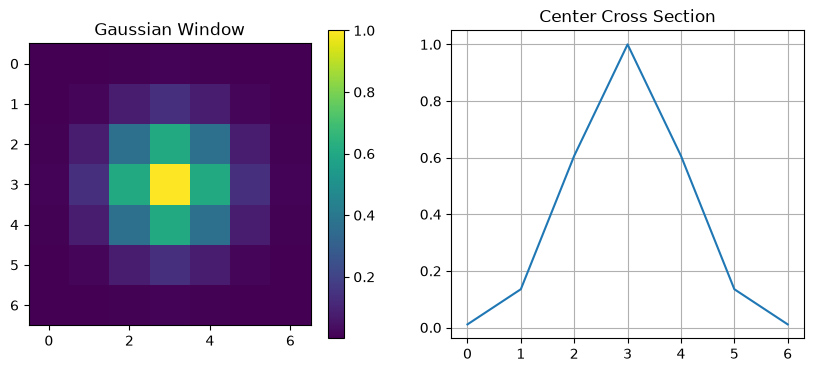

Window shape: (7, 7)
Max value (should be 1.0): 1.0
Center value (should be 1.0): 1.0
Corner value (should be small): 0.00012340980408667956
Window is symmetric: True


In [23]:
def test_gaussian_window():
    # Create a 7x7 window
    window = create_gaussian_window(7, sigma=1.0)
    
    # Visualize the window
    plt.figure(figsize=(10, 4))
    
    plt.subplot(121)
    plt.imshow(window, cmap='viridis')
    plt.colorbar()
    plt.title('Gaussian Window')
    
    plt.subplot(122)
    plt.plot(window[window.shape[0]//2, :])
    plt.title('Center Cross Section')
    plt.grid(True)
    plt.show()
    
    # Basic checks
    print("Window shape:", window.shape)
    print("Max value (should be 1.0):", window.max())
    print("Center value (should be 1.0):", window[window.shape[0]//2, window.shape[0]//2])
    print("Corner value (should be small):", window[0,0])
    
    # Check symmetry
    print("Window is symmetric:", np.allclose(window, window.T))

test_gaussian_window()

## Neighborhood Matching

Finds all neighborhoods in the source texture that are "similar enough" to the target neighborhood, and then randomly chooses one of them.


In [24]:
def find_matching_neighborhoods(target_neighborhood: np.ndarray,
                              source_texture: np.ndarray,
                              gaussian_window: np.ndarray,
                              valid_mask: np.ndarray,
                              threshold: float = 0.01) -> list:
    good_matches = []
    
    errors = []
    window_height, window_width = gaussian_window.shape
    half = window_height // 2
    height, width = source_texture.shape

    valid_weights = gaussian_window * valid_mask
    weight_sum = np.sum(valid_weights)
    valid_mask = valid_mask.astype(bool)
    
    for i in range(half, height - half):
        for j in range(half, width - half):
            source_window = source_texture[i - half : i + half + 1, j - half : j + half + 1]
            diff = np.sum((source_window - target_neighborhood) ** 2 * valid_weights) / weight_sum
            errors.append((diff, i, j))

    min_error = min(error for error, i, j in errors)
    error_threshold = min_error * (1 + threshold) ## Threshold for accepting neighborhood interpreted as the min_error * (100% + threshold%)
    for error, i, j in errors:
        if error <= error_threshold:
            good_matches.append((i, j))
    
    return good_matches

7 4
8 4
9 4
10 4
11 4
12 4


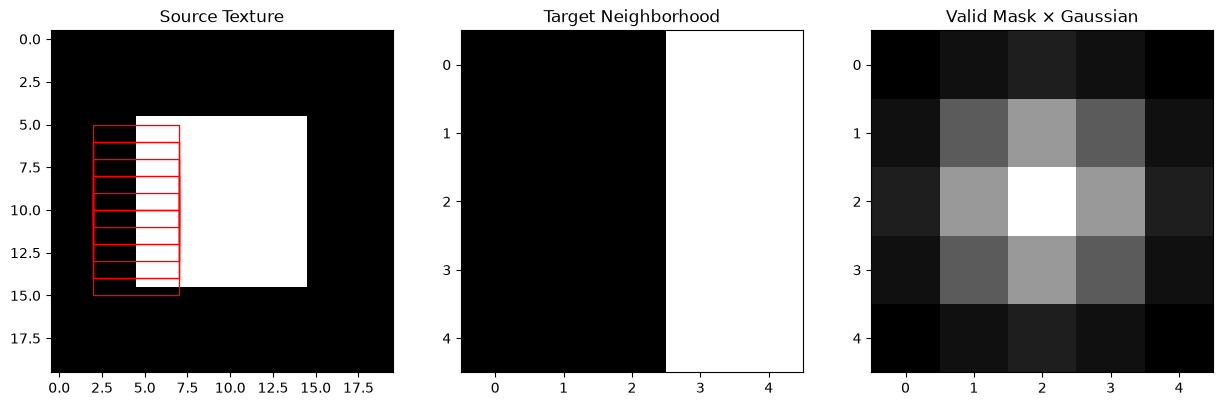

Found 6 matches


In [25]:
def test_neighborhood_matching():
    # Create a simple test texture
    source = np.zeros((20, 20))
    source[5:15, 5:15] = 1  # White square in center
    # Create a target neighborhood that should match the edge of the square
    window_size = 5
    target = np.zeros((window_size, window_size))
    target[:, :3] = 0
    target[:, 3:] = 1
    # Create valid mask (all pixels valid in this test)
    valid_mask = np.ones_like(target)
    # Create Gaussian window
    gaussian = create_gaussian_window(window_size)
    # Find matches
    matches = find_matching_neighborhoods(target, source, gaussian, valid_mask)
    # Visualize
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.imshow(source, cmap='gray')
    plt.title('Source Texture')
    # Highlight matches
    for i, j in matches:
        rect = plt.Rectangle((j-window_size//2, i-window_size//2), 
                           window_size, window_size, 
                           fill=False, color='red')
        print(i, j)
        plt.gca().add_patch(rect)
    plt.subplot(132)
    plt.imshow(target, cmap='gray')
    plt.title('Target Neighborhood')
    plt.subplot(133)
    plt.imshow(valid_mask * gaussian, cmap='gray')
    plt.title('Valid Mask × Gaussian')
    plt.show()
    
    print(f"Found {len(matches)} matches")

test_neighborhood_matching()

## Synthesis Loop

The synthesis loop grows the texture outward from an initial seed while carefully choosing the order of pixel synthesis and sampling from matching neighborhoods.


In [26]:
def synthesize_texture(source_texture: np.ndarray,
                       output_size: Tuple[int, int],
                       window_size: int = 15,
                       threshold: float = 0.01,
                       visualize: bool = True) -> np.ndarray:

    output = np.zeros(output_size)
    mask = np.zeros(output_size, dtype=bool)

    seed_size = 3
    seed_half = seed_size // 2
    window_half = window_size // 2
    sigma = window_size / 6.0 # Chose gaussian sigma to scale with window size so that as window size grows, farther pixels will still contribute meaningfully
    gaussian_window = create_gaussian_window(window_size, sigma)

    source_height, source_width = source_texture.shape
    output_height, output_width = output_size

    # Choose the center of a fully contained source seed.
    seed_row = random.randint(seed_half, source_height - seed_half - 1)
    seed_col = random.randint(seed_half, source_width - seed_half - 1)
    output_center_row = output_height // 2
    output_center_col = output_width // 2

    output[output_center_row - seed_half : output_center_row + seed_half + 1,
           output_center_col - seed_half : output_center_col + seed_half + 1] = source_texture[seed_row - seed_half : seed_row + seed_half + 1,
                                                                                               seed_col - seed_half : seed_col + seed_half + 1]

    mask[output_center_row - seed_half : output_center_row + seed_half + 1,
        output_center_col - seed_half : output_center_col + seed_half + 1] = True

    num_iter = output.size - np.count_nonzero(mask)

    for i in range(num_iter):
        counts = get_unfilled_neighbors_count(mask, window_size)

        max_count = np.max(counts)
        candidates = np.argwhere(counts == max_count)
        row, col = candidates[random.randrange(len(candidates))]

        padded_output = np.pad(output, pad_width=window_half, mode="constant", constant_values=0)
        padded_mask = np.pad(mask, pad_width=window_half, mode="constant", constant_values=False)
        target_neighborhood = padded_output[row : row + window_size, col : col + window_size]
        valid_mask = padded_mask[row : row + window_size, col : col + window_size]

        matches = find_matching_neighborhoods(
            target_neighborhood,
            source_texture,
            gaussian_window,
            valid_mask,
            threshold
        )

        if not matches:
            print("No matches found")

        source_row, source_col = matches[random.randrange(len(matches))]

        output[row, col] = source_texture[source_row, source_col]
        mask[row, col] = True

        if (i + 1) % 1000 == 0 and visualize:
            visualize_progress(output, mask, step=i + 1)

    return output

## Testing

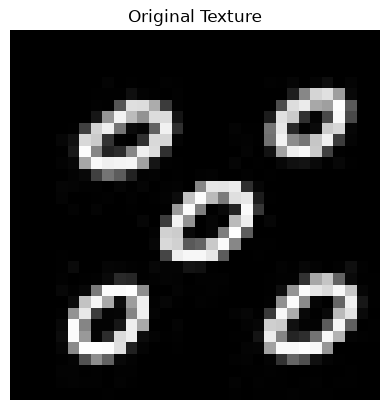

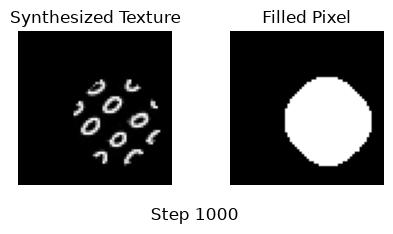

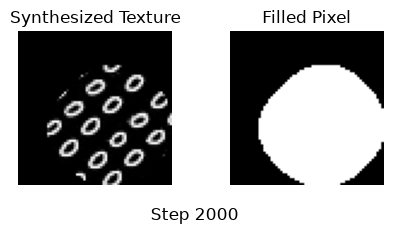

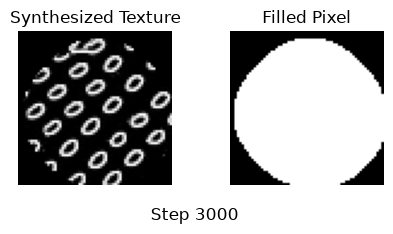

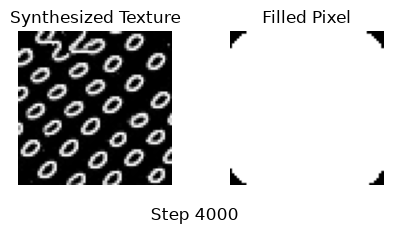

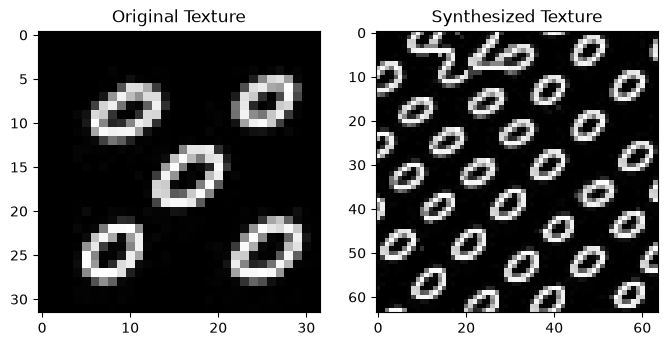

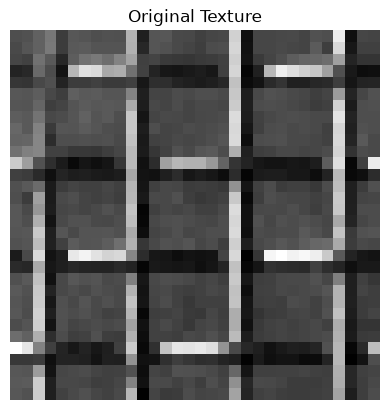

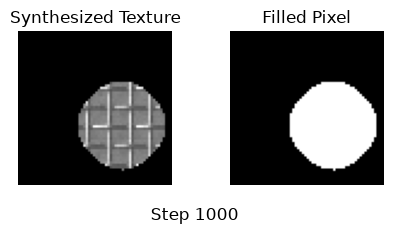

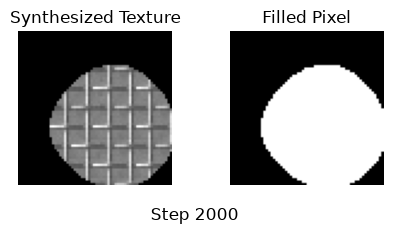

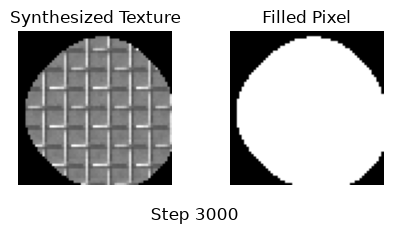

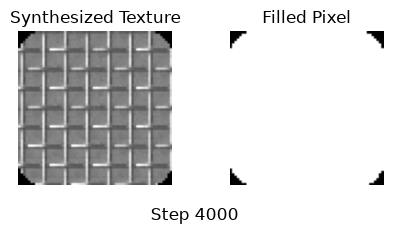

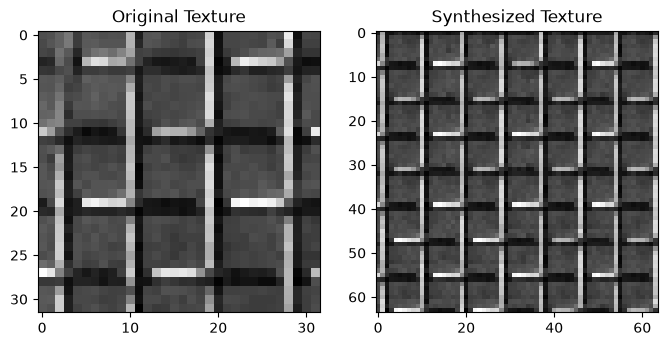

In [27]:
texture0 = 'textures/texture0.jpg'
texture1 = 'textures/texture1.jpg'
for texture_name in [texture0, texture1]:
    texture = load_texture(texture_name, (32, 32))
    
    synthesized = synthesize_texture(
        source_texture=texture,
        output_size=(64, 64),
        window_size=15,
        threshold=0.01
    )
    # Display results
    plt.figure(figsize=(8, 4))
    plt.subplot(121)
    plt.imshow(texture, cmap='gray')
    plt.title('Original Texture')
    plt.subplot(122)
    plt.imshow(synthesized, cmap='gray')
    plt.title('Synthesized Texture')
    plt.show()

## Varying parameters

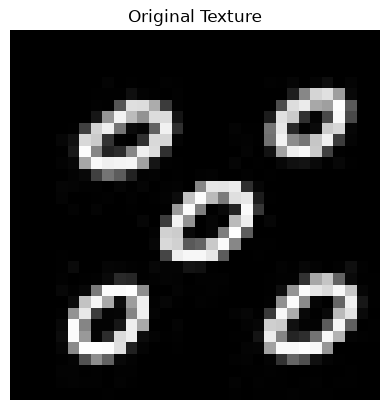

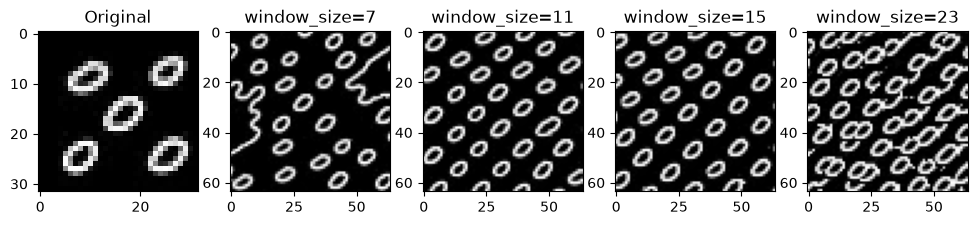

In [28]:
texture0 = 'textures/texture0.jpg'
random.seed(0)
texture = load_texture(texture0, (32, 32))
window_sizes = [7, 11, 15, 23]
plt.figure(figsize=(12, 4))
plt.subplot(1, len(window_sizes) + 1, 1)
plt.imshow(texture, cmap='grey')
plt.title('Original')
for i, window_size in enumerate(window_sizes):
    synthesized = synthesize_texture(
        source_texture=texture,
        output_size=(64, 64),
        window_size=window_size,
        threshold=0.01,
        visualize=False
    )
    plt.subplot(1, len(window_sizes) + 1, i+2)
    plt.imshow(synthesized, cmap='gray')
    plt.title(f"window_size={window_size}")
plt.show()

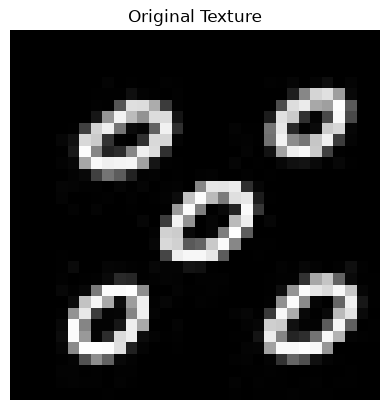

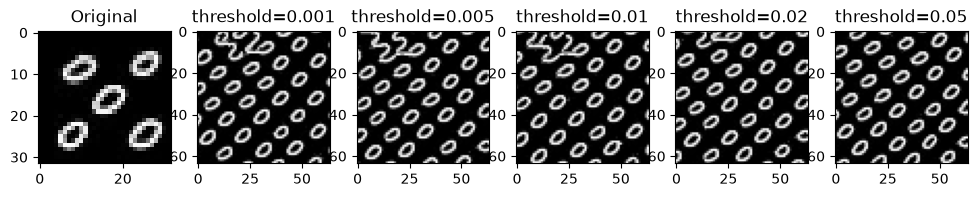

In [29]:
texture0 = 'textures/texture0.jpg'
random.seed(0)
texture = load_texture(texture0, (32, 32))
thresholds = [0.001, 0.005, 0.01, 0.02, 0.05]
plt.figure(figsize=(12, 4))
plt.subplot(1, len(thresholds) + 1, 1)
plt.imshow(texture, cmap='grey')
plt.title('Original')
for i, threshold in enumerate(thresholds):
    synthesized = synthesize_texture(
        source_texture=texture,
        output_size=(64, 64),
        window_size=15,
        threshold=threshold,
        visualize=False
    )
    plt.subplot(1, len(thresholds) + 1, i+2)
    plt.imshow(synthesized, cmap='gray')
    plt.title(f"threshold={threshold}")
plt.show()

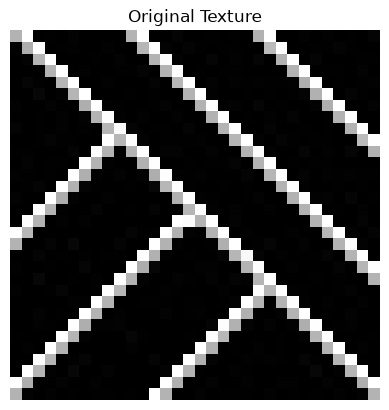

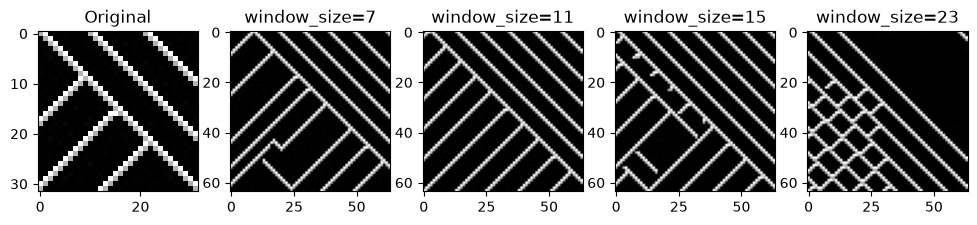

In [30]:
texture0 = 'textures/texture5.jpg'
random.seed(0)
texture = load_texture(texture0, (32, 32))
window_sizes = [7, 11, 15, 23]
plt.figure(figsize=(12, 4))
plt.subplot(1, len(window_sizes) + 1, 1)
plt.imshow(texture, cmap='grey')
plt.title('Original')
for i, window_size in enumerate(window_sizes):
    synthesized = synthesize_texture(
        source_texture=texture,
        output_size=(64, 64),
        window_size=window_size,
        threshold=0.01,
        visualize=False
    )
    plt.subplot(1, len(window_sizes) + 1, i+2)
    plt.imshow(synthesized, cmap='gray')
    plt.title(f"window_size={window_size}")
plt.show()

# Image Quilting
Modifies the previous texture synthesis algorithm to implement Image Quilting.

## Minimum Error Boundary Cuts Using Dp

Finds minimum error boundary cut between two overlapping blocks.

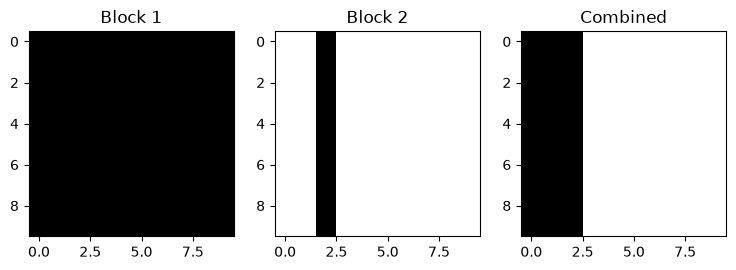

In [31]:
def min_error_boundary(
    block1: np.ndarray,
    block2: np.ndarray,
    overlap_size: int,
    direction: str = 'vertical'  # or 'horizontal'
) -> np.ndarray:
    if direction == 'horizontal':
        return min_error_boundary(block1.T, block2.T, overlap_size).T # Transpose gives us same result for horizontal seams

    # Both blocks are aligned at same output position, overlap is on left for vertical or on top for horizontal.
    # True selects block2 while false selects block1
    error = (block1[:, :overlap_size] - block2[:, :overlap_size]) ** 2
    parent = np.zeros(error.shape, dtype=int)
    height, width = error.shape

    for r in range(1, height):
        for c in range(width):
            left = max(0, c - 1)
            right = min(width, c + 2)
            previous = left + np.argmin(error[r - 1, left:right])
            error[r, c] += error[r - 1, previous]
            parent[r, c] = previous

    mask = np.ones(block1.shape, dtype=bool)
    c = np.argmin(error[-1])

    for r in range(height - 1, -1, -1):
        mask[r, :c] = False
        c = parent[r, c]

    return mask

block1 = np.zeros((10, 10))
block2 = np.ones((10, 10))
block2[:, 2] = 0 
mask = min_error_boundary(block1, block2, overlap_size=5)
result = np.where(mask, block2, block1)

plt.figure(figsize=(9, 3))
plt.subplot(131)
plt.imshow(block1, cmap='gray', vmin=0, vmax=1)
plt.title('Block 1')
plt.subplot(132)
plt.imshow(block2, cmap='gray', vmin=0, vmax=1)
plt.title('Block 2')
plt.subplot(133)
plt.imshow(result, cmap='gray', vmin=0, vmax=1)
plt.title('Combined')

plt.show()

## Image Quilting Synthesis Loop

In [32]:

def synthesize_texture_quilting(
    source_texture: np.ndarray,
    output_size: Tuple[int, int],
    block_size: int = 32,
    overlap_size: int = 8,
    threshold: float = 0.1,
    visualize: bool = True
) -> np.ndarray:
    output = np.zeros(output_size)
    mask = np.zeros(output_size, dtype=bool)

    source_height, source_width = source_texture.shape
    output_height, output_width = output_size
    step = block_size - overlap_size
    num_blocks = 0

    for row in range(0, max(1, output_height - overlap_size), step):
        for col in range(0, max(1, output_width - overlap_size), step):
            height = min(block_size, output_height - row)
            width = min(block_size, output_width - col)
            target_block = output[row : row + height, col : col + width]
            valid_mask = mask[row : row + height, col : col + width]
            if row == 0 and col == 0:
                source_row = random.randint(0, source_height - block_size)
                source_col = random.randint(0, source_width - block_size)
            else:
                errors = []

                for i in range(source_height - block_size + 1):
                    for j in range(source_width - block_size + 1):
                        source_block = source_texture[
                            i : i + height, j : j + width
                        ]

                        diff = np.sum(
                            (source_block - target_block) ** 2 * valid_mask
                        )
                        errors.append((diff, i, j))

                min_error = min(error for error, i, j in errors)
                error_threshold = min_error * (1 + threshold)
                matches = []
                for error, i, j in errors:
                    if error <= error_threshold:
                        matches.append((i, j))
                source_row, source_col = matches[
                    random.randrange(len(matches))
                ]

            source_block = source_texture[
                source_row : source_row + height,
                source_col : source_col + width
            ]

            take_new = np.ones((height, width), dtype=bool)

            if col > 0:
                left_mask = min_error_boundary(
                    target_block, source_block, overlap_size, 'vertical'
                )
                take_new = take_new & left_mask

            if row > 0:
                top_mask = min_error_boundary(
                    target_block, source_block, overlap_size, 'horizontal'
                )
                take_new = take_new & top_mask

            output[row : row + height, col : col + width] = np.where(
                take_new, source_block, target_block
            )
            mask[row : row + height, col : col + width] = True
            num_blocks += 1

        if visualize:
            visualize_progress(output, mask, step=num_blocks)

    return output

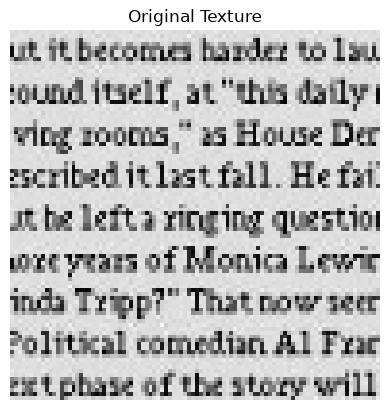

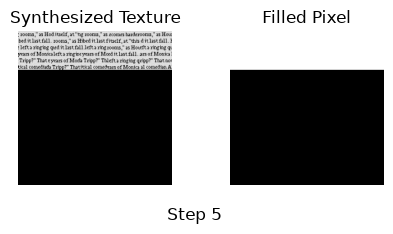

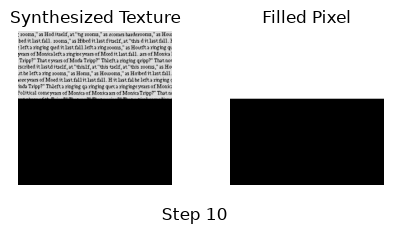

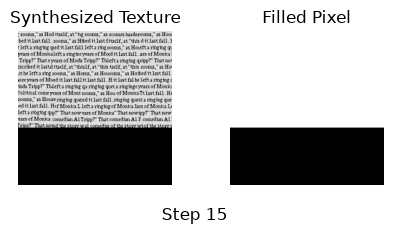

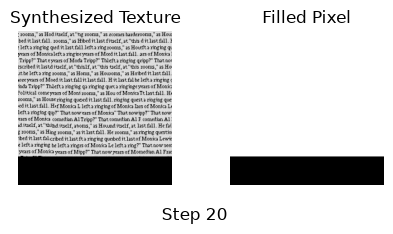

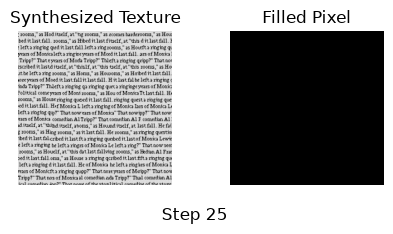

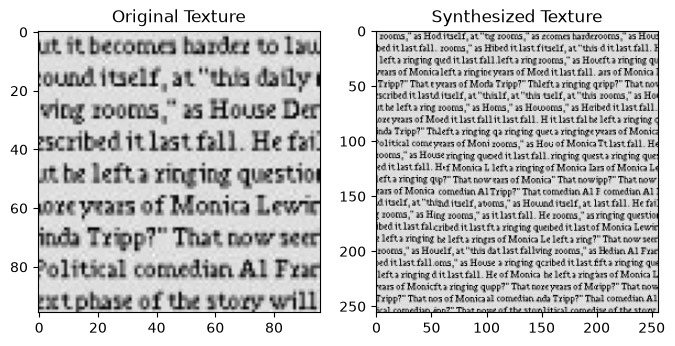

In [33]:
texture = load_texture("textures/texture3.jpg", (96, 96))

# Synthesize new texture
synthesized = synthesize_texture_quilting(
    source_texture=texture,
    output_size=(256, 256),
    block_size=64,
    overlap_size=16,
    threshold=0.1
)

# Display results
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(texture, cmap='gray')
plt.title('Original Texture')
plt.subplot(122)
plt.imshow(synthesized, cmap='gray')
plt.title('Synthesized Texture')

plt.show()